# **Model Building**

## **1. Install Necessary Libraries**

In [5]:
# Installing required libraries
!pip install scikit-learn -q
!pip install xgboost

# Importing necessary libraries
import pandas as pd
from datasets import load_dataset

# Importing StandardScaler
from sklearn.preprocessing import StandardScaler

# Importing Logistic Regression
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

# Importing Confusion Matrix Display
from sklearn.metrics import ConfusionMatrixDisplay

# Importing Model Evaluation Parameters
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

# Importing Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Importing evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# Importing Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Importing AdaBoost Classifier
from sklearn.ensemble import AdaBoostClassifier

# Importing Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

# Importing XGBoost Classifier
from xgboost import XGBClassifier

## **2. Load Training and Testing Datasets**

In [6]:
# Loading training dataset from Hugging Face

train_dataset = load_dataset(
    "gkrishna4346/predictive-maintenance-dataset",
    data_files="train_data.csv"
)

# Converting training dataset to DataFrame

train_df = train_dataset["train"].to_pandas()

# Displaying training dataset shape

print("Training Dataset Shape:", train_df.shape)

train_df.head()

Training Dataset Shape: (15628, 7)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,496,4.706240,5.249898,3.803385,75.033607,70.542095,0
1,836,3.960027,4.928546,3.705357,74.395016,84.098307,1
2,623,3.055244,9.494612,2.084725,76.865701,72.927688,0
3,675,2.785797,5.463947,1.649817,75.397279,82.907453,1
4,1412,2.816022,4.001410,1.921522,83.246013,71.176927,1


In [7]:
# Loading testing dataset from Hugging Face

test_dataset = load_dataset(
    "gkrishna4346/predictive-maintenance-dataset",
    data_files="test_data.csv"
)

# Converting testing dataset to DataFrame

test_df = test_dataset["train"].to_pandas()

# Displaying testing dataset shape

print("Testing Dataset Shape:", test_df.shape)

test_df.head()

Testing Dataset Shape: (3907, 7)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,634,2.611260,10.453517,2.771041,75.863640,79.245834,1
1,856,4.043840,5.829366,2.460446,73.860133,71.047078,1
2,814,4.073486,5.257120,1.866571,81.840070,76.715591,0
3,379,2.724639,4.712955,1.981593,77.092260,76.106727,1
4,868,2.672809,5.273917,1.905387,78.475478,72.088361,0


## **3. Feature and Target Separation**

In [8]:
# Separating features and target variable for training dataset

X_train = train_df.drop("Engine Condition", axis=1)
y_train = train_df["Engine Condition"]

# Separating features and target variable for testing dataset

X_test = test_df.drop("Engine Condition", axis=1)
y_test = test_df["Engine Condition"]

# Display dimensions

print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (15628, 6)
y_train Shape: (15628,)
X_test Shape : (3907, 6)
y_test Shape : (3907,)


**Observations:**

- The target variable `Engine Condition` was separated from the feature set for both training and testing datasets.

- The training feature set contains 15,628 records and 6 independent variables.

- The testing feature set contains 3,907 records and 6 independent variables.

- The datasets are now ready for feature scaling and model development.

## **4. Feature Scaling**

In [9]:
# Initializing StandardScaler

scaler = StandardScaler()

In [10]:
# Fitting scaler on training data and transforming datasets

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training Features Shape:", X_train_scaled.shape)
print("Testing Features Shape :", X_test_scaled.shape)

Training Features Shape: (15628, 6)
Testing Features Shape : (3907, 6)


In [11]:
# Converting scaled arrays to DataFrames for inspection

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_train_scaled_df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,-1.108206,1.364710,-0.507675,1.405131,-0.838207,-1.268547
1,0.163609,0.636647,-0.624032,1.310938,-1.042765,0.910824
2,-0.633146,-0.246129,1.029278,-0.246285,-0.251339,-0.885026
3,-0.438633,-0.509022,-0.430171,-0.664177,-0.721714,0.719376
4,2.318214,-0.479533,-0.959735,-0.403103,1.792444,-1.166488


## **5. Logistic Regression Model**

### **5.1. Building Logistic Regression Model**

In [12]:
# Building the model

lr_model = LogisticRegression(random_state=42)

# Training the model

lr_model.fit(X_train, y_train)

# Predictions

y_pred = lr_model.predict(X_test)

# Predicted probabilities

y_pred_prob = lr_model.predict_proba(X_test)[:, 1]

### **5.2. Evaluate Logistic Regression Model**

In [16]:
# Logistic Regression Model Evaluation

# Accuracy Score
lr_accuracy = accuracy_score(y_test, y_pred)

# ROC-AUC Score
lr_roc_auc = roc_auc_score(y_test, y_pred_prob)

print("Accuracy Score:", lr_accuracy)
print("ROC-AUC Score:", lr_roc_auc)

# Confusion Matrix

lr_cm = confusion_matrix(y_test, y_pred)
print(lr_cm)

# Classification Report

print(classification_report(y_test, y_pred))

Accuracy Score: 0.6560020476068594
ROC-AUC Score: 0.6803821207612273
[[ 393 1051]
 [ 293 2170]]
              precision    recall  f1-score   support

           0       0.57      0.27      0.37      1444
           1       0.67      0.88      0.76      2463

    accuracy                           0.66      3907
   macro avg       0.62      0.58      0.57      3907
weighted avg       0.64      0.66      0.62      3907



### **5.3. Confusion Matrix Heatmap**

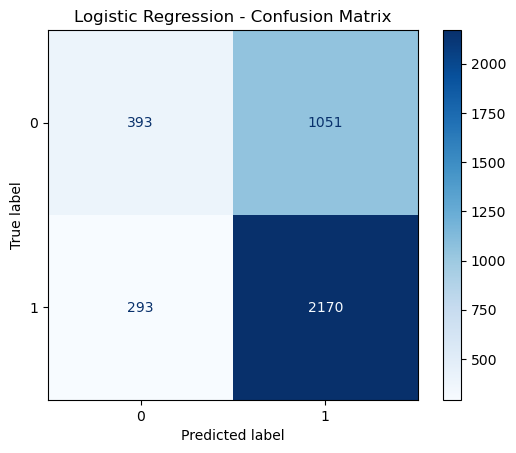

In [17]:
# Creating and displaying Confusion Matrix Heatmap for Logistic Regression Model

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Logistic Regression - Confusion Matrix")

plt.show()

### **5.4. Logistic Regression - Observations**

* The Logistic Regression model achieved an accuracy score of 65.60%.

* The ROC-AUC score obtained is 68.04%.

* The model correctly classified 393 non-failure cases and 2170 failure cases.

* The model misclassified 1051 non-failure cases and 293 failure cases.

* The precision, recall, and F1-score for Class 1 are higher than those for Class 0.

* The model predicts failure cases better than non-failure cases.ning models.ning models.

## **Creating Model Comparison Dictionary**

In [19]:
# Creating Model Comparison Dictionary and Updating scores post completion of every Model

model_results = {
    "Model": ["Logistic Regression"],
    "Accuracy": [lr_accuracy],
    "ROC_AUC": [lr_roc_auc],
    "Precision": [precision_score(y_test, y_pred)],
    "Recall": [recall_score(y_test, y_pred)],
    "F1_Score": [f1_score(y_test, y_pred)]
}

results_df = pd.DataFrame(model_results)

results_df

,Model,Accuracy,ROC_AUC,Precision,Recall,F1_Score
0,Logistic Regression,0.656002,0.680382,0.673704,0.881039,0.763547


## **6. Decision Tree Model**

### **6.1. Building Decision Tree Model**

In [20]:
# Creating the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Training the model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Predicting probabilities for ROC-AUC Score
y_pred_dt_prob = dt_model.predict_proba(X_test)[:, 1]

### **6.2. Evaluate Decision Tree Model**

In [21]:
# Decision Tree Model Evaluation

# Calculate Accuracy Score
dt_accuracy = accuracy_score(y_test, y_pred_dt)

# Calculate ROC-AUC Score
dt_roc_auc = roc_auc_score(y_test, y_pred_dt_prob)

# Display results
print("Decision Tree Accuracy Score:", round(dt_accuracy, 4))
print("Decision Tree ROC-AUC Score:", round(dt_roc_auc, 4))

# Confusion Matrix
dt_cm = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix:")
print(dt_cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy Score: 0.593
Decision Tree ROC-AUC Score: 0.561

Confusion Matrix:
[[ 633  811]
 [ 779 1684]]

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.44      0.44      1444
           1       0.67      0.68      0.68      2463

    accuracy                           0.59      3907
   macro avg       0.56      0.56      0.56      3907
weighted avg       0.59      0.59      0.59      3907



### **6.3. Confusion Matrix Heatmap**

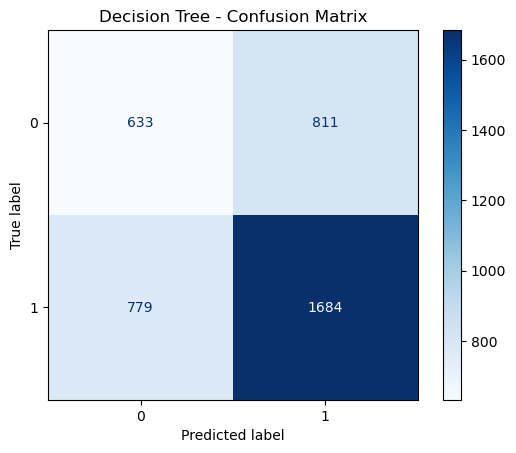

In [22]:
# Creating and displaying Decision Tree Confusion Matrix Heatmap for Decision Tree Model

disp = ConfusionMatrixDisplay(
    confusion_matrix=dt_cm
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Decision Tree - Confusion Matrix")

plt.show()

### **6.4. Decision Tree - Observations**

* The Decision Tree model achieved an accuracy score of 59.30%.

* The ROC-AUC score obtained is 56.10%.

* The model correctly classified 633 non-failure cases and 1684 failure cases.

* The model misclassified 811 non-failure cases and 779 failure cases.

* The precision for Class 1 is 0.67 and the recall is 0.68.

* The model shows lower performance compared to the Logistic Regression model in terms of Accuracy and ROC-AUC score.

## **Appending Model Comparison Dictionary**

In [23]:
# Appending the scores to Model Comparison Dictionary post Decision Tree Model done
results_df.loc[len(results_df)] = [
    "Decision Tree",
    dt_accuracy,
    dt_roc_auc,
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt)
]

results_df

,Model,Accuracy,ROC_AUC,Precision,Recall,F1_Score
0,Logistic Regression,0.656002,0.680382,0.673704,0.881039,0.763547
1,Decision Tree,0.593038,0.561042,0.674950,0.683719,0.679306


## **7. Random Forest Model**

### **7.1. Building Decision Tree Model**

In [24]:
# Building Random Forest Model

# Creating the Random Forest model
rf_model = RandomForestClassifier(
    random_state=42
)

# Training the model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Predicting probabilities for ROC-AUC Score
y_pred_rf_prob = rf_model.predict_proba(X_test)[:, 1]

### **7.2. Evaluate Random Forest Model**

In [25]:
# Evaluating Random Forest Model

# Calculating Accuracy Score
rf_accuracy = accuracy_score(y_test, y_pred_rf)

# Calculating ROC-AUC Score
rf_roc_auc = roc_auc_score(y_test, y_pred_rf_prob)

# Displaying results
print("Random Forest Accuracy Score:", round(rf_accuracy, 4))
print("Random Forest ROC-AUC Score:", round(rf_roc_auc, 4))

# Confusion Matrix
rf_cm = confusion_matrix(y_test, y_pred_rf)

print("\nConfusion Matrix:")
print(rf_cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy Score: 0.6453
Random Forest ROC-AUC Score: 0.6773

Confusion Matrix:
[[ 556  888]
 [ 498 1965]]

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.39      0.45      1444
           1       0.69      0.80      0.74      2463

    accuracy                           0.65      3907
   macro avg       0.61      0.59      0.59      3907
weighted avg       0.63      0.65      0.63      3907



### **7.3. Confusion Matrix Heatmap**

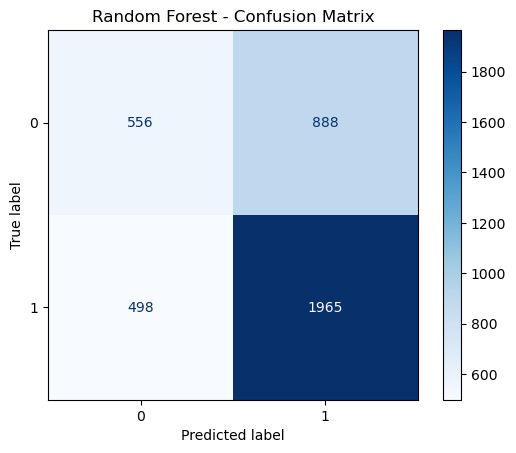

In [26]:
# Creating and displaying Random Forest Confusion Matrix Heatmap for Random Forest Model

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Random Forest - Confusion Matrix")

plt.show()

### **7.4. Random Forest - Observations**

* The Random Forest model achieved an accuracy score of 64.53%.

* The ROC-AUC score obtained is 67.73%.

* The model correctly classified 556 non-failure cases and 1965 failure cases.

* The model misclassified 888 non-failure cases and 498 failure cases.

* The precision for Class 1 is 0.69 and the recall is 0.80.

* The Random Forest model performed better than the Decision Tree model and showed performance comparable to Logistic Regression.

## **Appending Model Comparison Dictionary**

In [27]:
# Appending the scores to Model Comparison Dictionary post Random Forest Model

results_df.loc[len(results_df)] = [
    "Random Forest",
    rf_accuracy,
    rf_roc_auc,
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

results_df

,Model,Accuracy,ROC_AUC,Precision,Recall,F1_Score
0,Logistic Regression,0.656002,0.680382,0.673704,0.881039,0.763547
1,Decision Tree,0.593038,0.561042,0.674950,0.683719,0.679306
2,Random Forest,0.645252,0.677300,0.688749,0.797808,0.739278


## **8. AdaBoost Model**

### **8.1. Building AdaBoost Model**

In [28]:
# Building AdaBoost Model

# Creating the AdaBoost model
ab_model = AdaBoostClassifier(
    random_state=42
)

# Training the model
ab_model.fit(X_train, y_train)

# Predictions
y_pred_ab = ab_model.predict(X_test)

# Predicting probabilities for ROC-AUC Score
y_pred_ab_prob = ab_model.predict_proba(X_test)[:, 1]

In [49]:
import sklearn
print(sklearn.__version__)

1.2.2


### **8.2. Evaluate AdaBoost Model**

In [29]:
# Evaluating AdaBoost Model

# Calculating Accuracy Score
ab_accuracy = accuracy_score(y_test, y_pred_ab)

# Calculating ROC-AUC Score
ab_roc_auc = roc_auc_score(y_test, y_pred_ab_prob)

# Displaying results
print("AdaBoost Accuracy Score:", round(ab_accuracy, 4))
print("AdaBoost ROC-AUC Score:", round(ab_roc_auc, 4))

# Confusion Matrix
ab_cm = confusion_matrix(y_test, y_pred_ab)

print("\nConfusion Matrix:")
print(ab_cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ab))

AdaBoost Accuracy Score: 0.6688
AdaBoost ROC-AUC Score: 0.705

Confusion Matrix:
[[ 552  892]
 [ 402 2061]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.38      0.46      1444
           1       0.70      0.84      0.76      2463

    accuracy                           0.67      3907
   macro avg       0.64      0.61      0.61      3907
weighted avg       0.65      0.67      0.65      3907



### **8.3. Confusion Matrix Heatmap**

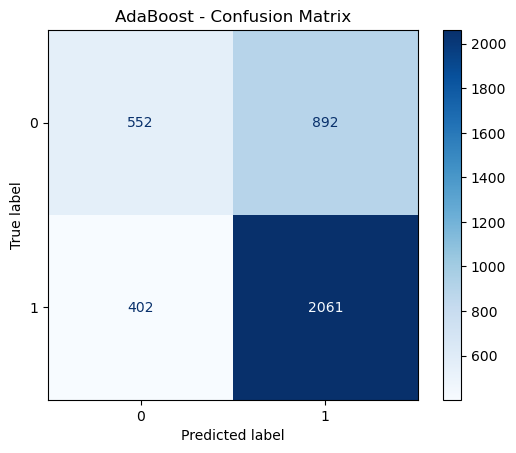

In [30]:
# Creating and displaying Confusion Matrix Heatmap

disp = ConfusionMatrixDisplay(
    confusion_matrix=ab_cm
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("AdaBoost - Confusion Matrix")

plt.show()

### **8.4. AdaBoost - Observations**

* The AdaBoost model achieved an accuracy score of 66.88%.

* The ROC-AUC score obtained is 70.50%.

* The model correctly classified 552 non-failure cases and 2061 failure cases.

* The model misclassified 892 non-failure cases and 402 failure cases.

* The precision for Class 1 is 0.70 and the recall is 0.84.

* The AdaBoost model performed better than the Logistic Regression, Decision Tree, and Random Forest models in terms of ROC-AUC score.

## **Appending Model Comparison Dictionary**

In [31]:
# Appending the scores to Model Comparison Dictionary post AdaBoost Model

results_df.loc[len(results_df)] = [
    "AdaBoost",
    ab_accuracy,
    ab_roc_auc,
    precision_score(y_test, y_pred_ab),
    recall_score(y_test, y_pred_ab),
    f1_score(y_test, y_pred_ab)
]

results_df

,Model,Accuracy,ROC_AUC,Precision,Recall,F1_Score
0,Logistic Regression,0.656002,0.680382,0.673704,0.881039,0.763547
1,Decision Tree,0.593038,0.561042,0.674950,0.683719,0.679306
2,Random Forest,0.645252,0.677300,0.688749,0.797808,0.739278
3,AdaBoost,0.668800,0.704980,0.697934,0.836784,0.761078


## **9. Gradient Boosting Model**

### **9.1. Building Gradient Boosting Model**

In [32]:
# Building Gradient Boosting Model

# Creating the Gradient Boosting model
gb_model = GradientBoostingClassifier(
    random_state=42
)

# Training the model
gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)

# Predicting probabilities for ROC-AUC Score
y_pred_gb_prob = gb_model.predict_proba(X_test)[:, 1]

### **9.2. Evaluate Gradient Boosting Model**

In [33]:
# Evaluating Gradient Boosting Model

# Calculating Accuracy Score
gb_accuracy = accuracy_score(y_test, y_pred_gb)

# Calculating ROC-AUC Score
gb_roc_auc = roc_auc_score(y_test, y_pred_gb_prob)

# Displaying results
print("Gradient Boosting Accuracy Score:", round(gb_accuracy, 4))
print("Gradient Boosting ROC-AUC Score:", round(gb_roc_auc, 4))

# Confusion Matrix
gb_cm = confusion_matrix(y_test, y_pred_gb)

print("\nConfusion Matrix:")
print(gb_cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy Score: 0.6647
Gradient Boosting ROC-AUC Score: 0.7035

Confusion Matrix:
[[ 519  925]
 [ 385 2078]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.36      0.44      1444
           1       0.69      0.84      0.76      2463

    accuracy                           0.66      3907
   macro avg       0.63      0.60      0.60      3907
weighted avg       0.65      0.66      0.64      3907



### **9.3. Confusion Matrix Heatmap**

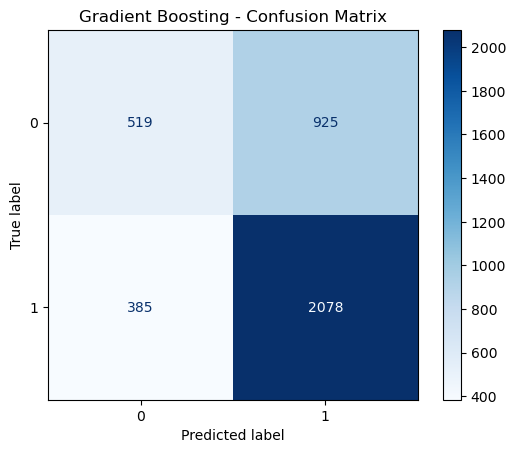

In [34]:
# Creating and displaying Confusion Matrix Heatmap

disp = ConfusionMatrixDisplay(
    confusion_matrix=gb_cm
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Gradient Boosting - Confusion Matrix")

plt.show()

### **9.4. Gradient Boosting - Observations**

* The Gradient Boosting model achieved an accuracy score of 66.47%.

* The ROC-AUC score obtained is 70.35%.

* The model correctly classified 519 non-failure cases and 2078 failure cases.

* The model misclassified 925 non-failure cases and 385 failure cases.

* The precision for Class 1 is 0.69 and the recall is 0.84.

* The Gradient Boosting model performed better than Logistic Regression, Decision Tree, and Random Forest in terms of ROC-AUC score.

* The Gradient Boosting model performed similarly to the AdaBoost model, with slightly lower Accuracy and ROC-AUC scores.

### **9.5. Appending Model Comparison Dictionary**

In [35]:
# Appending the scores to Model Comparison Dictionary post Gradient Bossting Model

results_df.loc[len(results_df)] = [
    "Gradient Boosting",
    gb_accuracy,
    gb_roc_auc,
    precision_score(y_test, y_pred_gb),
    recall_score(y_test, y_pred_gb),
    f1_score(y_test, y_pred_gb)
]

results_df

,Model,Accuracy,ROC_AUC,Precision,Recall,F1_Score
0,Logistic Regression,0.656002,0.680382,0.673704,0.881039,0.763547
1,Decision Tree,0.593038,0.561042,0.674950,0.683719,0.679306
2,Random Forest,0.645252,0.677300,0.688749,0.797808,0.739278
3,AdaBoost,0.668800,0.704980,0.697934,0.836784,0.761078
4,Gradient Boosting,0.664704,0.703469,0.691975,0.843687,0.760337


## **10. XGBoost Model**

### **10.1. Building XGBoost Model**

In [36]:
# Creating the XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Training the model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Predicting probabilities for ROC-AUC Score
y_pred_xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

### **10.2. Evaluate XGBoost Model**

In [37]:
# Evaluating XGBoost Model

# Calculating Accuracy Score
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

# Calculating ROC-AUC Score
xgb_roc_auc = roc_auc_score(y_test, y_pred_xgb_prob)

# Displaying results
print("XGBoost Accuracy Score:", round(xgb_accuracy, 4))
print("XGBoost ROC-AUC Score:", round(xgb_roc_auc, 4))

# Confusion Matrix
xgb_cm = confusion_matrix(y_test, y_pred_xgb)

print("\nConfusion Matrix:")
print(xgb_cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy Score: 0.6455
XGBoost ROC-AUC Score: 0.67

Confusion Matrix:
[[ 583  861]
 [ 524 1939]]

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.40      0.46      1444
           1       0.69      0.79      0.74      2463

    accuracy                           0.65      3907
   macro avg       0.61      0.60      0.60      3907
weighted avg       0.63      0.65      0.63      3907



### **10.3. Confusion Matrix Heatmap**

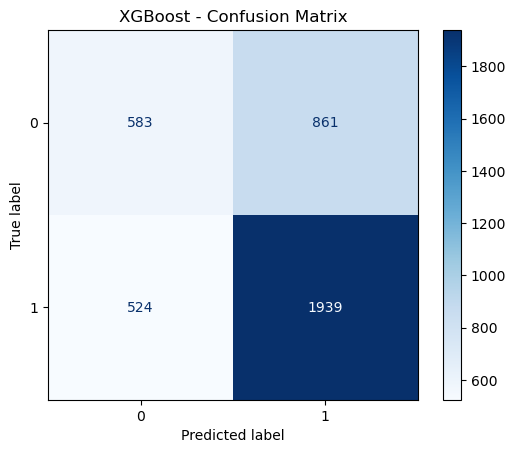

In [38]:
# Creating and displaying Confusion Matrix Heatmap for XGBoost Model

disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("XGBoost - Confusion Matrix")

plt.show()

### **10.4. XGBoost - Observations**

* The XGBoost model achieved an accuracy score of 64.55%.

* The ROC-AUC score obtained is 67.00%.

* The model correctly classified 583 non-failure cases and 1939 failure cases.

* The model misclassified 861 non-failure cases and 524 failure cases.

* The precision for Class 1 is 0.69 and the recall is 0.79.

* The XGBoost model performed better than the Decision Tree model but lower than the AdaBoost and Gradient Boosting models in terms of Accuracy and ROC-AUC score.

### **10.5. Appending Model Comparison Dictionary**

In [39]:
# Appending the scores to Model Comparison Dictionary post XGBoost Model

results_df.loc[len(results_df)] = [
    "XGBoost",
    xgb_accuracy,
    xgb_roc_auc,
    precision_score(y_test, y_pred_xgb),
    recall_score(y_test, y_pred_xgb),
    f1_score(y_test, y_pred_xgb)
]

results_df

,Model,Accuracy,ROC_AUC,Precision,Recall,F1_Score
0,Logistic Regression,0.656002,0.680382,0.673704,0.881039,0.763547
1,Decision Tree,0.593038,0.561042,0.674950,0.683719,0.679306
2,Random Forest,0.645252,0.677300,0.688749,0.797808,0.739278
3,AdaBoost,0.668800,0.704980,0.697934,0.836784,0.761078
4,Gradient Boosting,0.664704,0.703469,0.691975,0.843687,0.760337
5,XGBoost,0.645508,0.669978,0.692500,0.787251,0.736842


## **17. Model Comparison**

In [40]:
results_df

,Model,Accuracy,ROC_AUC,Precision,Recall,F1_Score
0,Logistic Regression,0.656002,0.680382,0.673704,0.881039,0.763547
1,Decision Tree,0.593038,0.561042,0.674950,0.683719,0.679306
2,Random Forest,0.645252,0.677300,0.688749,0.797808,0.739278
3,AdaBoost,0.668800,0.704980,0.697934,0.836784,0.761078
4,Gradient Boosting,0.664704,0.703469,0.691975,0.843687,0.760337
5,XGBoost,0.645508,0.669978,0.692500,0.787251,0.736842


### **11.1 Model Comparison Observations**

* Six machine learning models were evaluated for predictive maintenance prediction.

* AdaBoost achieved the highest Accuracy Score of 66.88% and ROC-AUC Score of 70.50%.

* Gradient Boosting achieved similar performance with an Accuracy Score of 66.47% and ROC-AUC Score of 70.35%.

* Logistic Regression achieved the highest Recall Score of 88.10% and the highest F1-Score of 76.35%.

* Random Forest and XGBoost showed moderate performance but did not outperform AdaBoost and Gradient Boosting.

* Decision Tree achieved the lowest Accuracy and ROC-AUC scores among all the models.

* Based on the overall evaluation metrics, AdaBoost was selected as the best-performing model for this dataset.

## **12. Hyperparameter Tuning (AdaBoost)**

### **12.1. Define Parameter Grid**

In [41]:
# Defining Parameter Grid for AdaBoost

param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1.0]
}

print("Parameter Grid:")
print(param_grid)

Parameter Grid:
{'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1.0]}


### **12.2. GridSearchCV**

In [43]:
# Hyperparameter Tuning using GridSearchCV

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier

# Creating AdaBoost tuned model
ab_tuned = AdaBoostClassifier(
    random_state=42
)

# Performing Grid Search
grid_search = GridSearchCV(
    estimator=ab_tuned,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

# Fitting Grid Search
grid_search.fit(X_train, y_train)

print("Grid Search Completed")

Grid Search Completed


### **12.3. Best Parameters**

In [44]:
# Best Parameters

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest ROC-AUC Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'learning_rate': 0.1, 'n_estimators': 200}

Best ROC-AUC Score:
0.7012


### **12.4. Evaluate Tuned AdaBoost**

In [45]:
# Evaluating Tuned AdaBoost Model

best_ab_model = grid_search.best_estimator_

# Predictions
y_pred_ab_tuned = best_ab_model.predict(X_test)

# Prediction probabilities
y_pred_ab_tuned_prob = best_ab_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

ab_tuned_accuracy = accuracy_score(
    y_test,
    y_pred_ab_tuned
)

ab_tuned_roc_auc = roc_auc_score(
    y_test,
    y_pred_ab_tuned_prob
)

print("Tuned AdaBoost Accuracy Score:",
      round(ab_tuned_accuracy, 4))

print("Tuned AdaBoost ROC-AUC Score:",
      round(ab_tuned_roc_auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ab_tuned))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_ab_tuned
))

Tuned AdaBoost Accuracy Score: 0.6647
Tuned AdaBoost ROC-AUC Score: 0.7031

Confusion Matrix:
[[ 498  946]
 [ 364 2099]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.34      0.43      1444
           1       0.69      0.85      0.76      2463

    accuracy                           0.66      3907
   macro avg       0.63      0.60      0.60      3907
weighted avg       0.65      0.66      0.64      3907



### **12.5. Tuned Model Observations**

* Hyperparameter tuning was performed using GridSearchCV with different combinations of n_estimators and learning_rate.

* The best parameters identified were:

   * learning_rate = 0.1

   * n_estimators = 200

* The tuned AdaBoost model achieved an Accuracy Score of 66.47%.

* The ROC-AUC score obtained was 70.31%.

* The model correctly classified 498 non-failure cases and 2099 failure cases.

* The model misclassified 946 non-failure cases and 364 failure cases.

* The tuned model achieved a Recall Score of 85%, which is slightly higher than the baseline AdaBoost model.

* However, the tuned model showed a slight decrease in Accuracy and ROC-AUC compared to the baseline AdaBoost model.

* Based on the overall performance metrics, the baseline AdaBoost model was retained as the final selected model for this project.

## **13. Model Registration**

### **13.1. Save AdaBoost Model**

In [48]:
# Importing joblib

import joblib

# Saving the selected AdaBoost model

joblib.dump(
    ab_model,
    "adaboost_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


### **13.2. Registering the Model in Hugging Face Model Hub**

* The selected AdaBoost model was saved as a pickle file using Joblib.

* A model repository named predictive-maintenance-adaboost was created in the Hugging Face Model Hub.

* The model file (adaboost_model.pkl) and model card (README.md) were uploaded to the repository.

* The registered model can be accessed through the Hugging Face Model Hub for future use and deployment.

* **Model Repository Link** - https://huggingface.co/gkrishna4346/predictive-maintenance-adaboost

## **14. Feature Importance Analysis**

### **14.1 Extract Feature Importance**

In [ ]:
# Extracting Feature Importance from the best model selected

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": ab_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

### **14.2. Feature Importance Visualization**

In [ ]:
# Feature Importance Visualization

# Converting importance to percentage
feature_importance_plot = feature_importance.copy()
feature_importance_plot["Importance (%)"] = (
    feature_importance_plot["Importance"] * 100
)

plt.figure(figsize=(10, 5))

bars = plt.barh(
    feature_importance_plot["Feature"],
    feature_importance_plot["Importance (%)"],
    color="#4C72B0"
)

# Adding percentage labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{width:.0f}%",
        va="center"
    )

plt.xlabel("Importance (%)")
plt.ylabel("Feature")
plt.title("AdaBoost Feature Importance")

# Adding some breathing space
plt.xlim(0, 50)

# Showing highest importance at top
plt.gca().invert_yaxis()

plt.show()

### **14.3 Feature Importance Observations:**

* Engine rpm is the most important feature with an importance score of 30%.

* Lub oil temperature and Fuel pressure are the next most influential features with importance scores of 22% and 20%, respectively.

* Lub oil pressure contributes 12% to the model predictions.

* Coolant pressure and Coolant temperature have relatively lower importance scores of 10% and 6%, respectively.

* The results indicate that engine speed, lubrication system parameters, and fuel pressure play a significant role in predicting machine failures.

* Monitoring these critical parameters can help in identifying potential failures and improving maintenance planning.

## **15. Recommendations**

* Implement continuous monitoring of critical machine parameters such as Engine rpm, Lub oil temperature, and Fuel pressure.

* Establish threshold-based alerts for highly influential features to identify potential failures at an early stage.

* Prioritize preventive maintenance activities for machines exhibiting abnormal readings in critical parameters.

* Use the AdaBoost model as a decision-support tool for predicting machine failures and planning maintenance schedules.

* Periodically retrain the model with new operational data to maintain prediction performance.

## **16. Conclusions- Best Model Selection**

* Six machine learning models were evaluated for predictive maintenance prediction.

* AdaBoost achieved the highest Accuracy Score (66.88%) and ROC-AUC Score (70.50%) among all evaluated models.

* Therefore, AdaBoost was selected as the best-performing model for this dataset.

* Feature importance analysis showed that Engine rpm, Lub oil temperature, and Fuel pressure were the most influential predictors of machine failure.

* The selected model can be used to support predictive maintenance strategies and reduce unexpected equipment downtime.

* Future improvements may include hyperparameter tuning, feature engineering, and testing additional machine learning algorithms to further improve performance.